In [3]:
import json
from pathlib import Path
import shutil
import random
import numpy as np


FOLDER = r"D:\books-dataset\yolo-exp-etl-data\test\json_only"

# 统计标签

In [ ]:
label_set = set()
file_count = 0

for file in Path(FOLDER).rglob("*.json"):
    json_obj = json.load(open(file, "r", encoding="utf-8"))
    for shape in json_obj["shapes"]:
        label_set.add(shape["label"])

    file_count += 1

print(f"处理{file_count}个文件，标签为{label_set}")

处理3328个文件，标签为{'Vitium', 'Inkiness', 'Crease', 'Patch', 'Book', 'defaced', 'Signature'}


# 修复shape_type=points

In [11]:
for file in Path(FOLDER).rglob("*.json"):
    json_obj = json.load(open(file, "r", encoding="utf-8"))
    for shape in json_obj["shapes"]:
        if shape["shape_type"] == "points":
            print(file)

D:\books-dataset\yolo-exp-etl-data\train\json_only\01b15af2c250370fbb_b.json
D:\books-dataset\yolo-exp-etl-data\train\json_only\01b15d125a87fa8e72_b.json
D:\books-dataset\yolo-exp-etl-data\train\json_only\0c35e6e527eade12_b.json
D:\books-dataset\yolo-exp-etl-data\train\json_only\2a6d4395f8836cc8_b.json


In [12]:
save_flag = False

for file in Path(FOLDER).rglob("*.json"):
    json_obj = json.load(open(file, "r", encoding="utf-8"))
    for shape in json_obj["shapes"]:
        if shape["shape_type"] == "points":
            shape["shape_type"] = "polygon"
            save_flag = True

    if save_flag:
        with open(file, "w", encoding="utf-8") as f:
            f.write(json.dumps(json_obj, indent=2))
        print(f"文件{file}的shape_type已修改为polygon")
        save_flag = False

文件D:\books-dataset\yolo-exp-etl-data\train\json_only\01b15af2c250370fbb_b.json的shape_type已修改为polygon
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\01b15d125a87fa8e72_b.json的shape_type已修改为polygon
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\0c35e6e527eade12_b.json的shape_type已修改为polygon
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\2a6d4395f8836cc8_b.json的shape_type已修改为polygon


# 删除点个数<=2 和非polygon

In [13]:
issue_file_count = 0
save_flag = False

for file in Path(FOLDER).rglob("*.json"):
    json_obj = json.load(open(file, "r", encoding="utf-8"))
    remove_shapes = []
    for shape in json_obj["shapes"]:
        if shape["shape_type"] != "polygon":
            remove_shapes.append(shape)
            save_flag = True
        if shape["shape_type"] == "polygon" and len(shape["points"]) <= 2:
            # json_obj["shapes"].remove(shape)
            remove_shapes.append(shape)
            save_flag = True

    if save_flag:
        for rs in remove_shapes:
            json_obj["shapes"].remove(rs)
        with open(file, "w", encoding="utf-8") as f:
            f.write(json.dumps(json_obj, indent=2))
        save_flag = False
        issue_file_count += 1
        print(f"文件{file}保存成功")

print(f"共修复{issue_file_count}个文件")

文件D:\books-dataset\yolo-exp-etl-data\train\json_only\000735f0977d3365_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\00192347733ce827_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\002c9b97b56be38c_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\004b598c0071e8a6_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\005d809f9c2abc16_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\00a267879fe83bd5_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\00dc207fa534ae23_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\00f2cd211a578202_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\0103aa14ba85c5475e_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\0103aa17eea4218c57_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\0103aa1a5a7fa7e4c0_b.json保存成功
文件D:\books-dataset\yolo-exp-etl-data\train\json_only\0103aa20d639289eeb_b.json保存成功
文件D:\books-dataset\y

#  验证集文件太多 从验证集移动文件到训练集

In [ ]:
TRAIN_DIR = r"D:\books-dataset\yolo-exp-etl-data\train\json_only"
VAL_DIR = r"D:\books-dataset\yolo-exp-etl-data\val\json_only"

val_list = list(Path(VAL_DIR).rglob("*.json"))

print(len(val_list))
sampled = random.sample(val_list, 400)
for s in sampled:
    shutil.move(s, TRAIN_DIR)


list(Path(VAL_DIR).rglob("*.json")).__len__()

955


555

In [26]:
list(Path(VAL_DIR).glob("*.json")).__len__()

555

# 确保Book分类在索引0

In [37]:
for file in Path(FOLDER).rglob("*.json"):
    json_obj = json.load(open(file, "r", encoding="utf-8"))
    remove_shapes = []
    for shape in json_obj["shapes"]:
        if shape['label'] != "Book":
            print(file)
        break

D:\books-dataset\yolo-exp-etl-data\test\json_only\9f3757cb1edf9ff0_b.json
D:\books-dataset\yolo-exp-etl-data\test\json_only\c82af656478875f6_b.json


# 保存mask

In [151]:
import base64
from PIL import Image, ImageDraw
from io import BytesIO
import matplotlib.pyplot as plt


names = ["Book", "Inkiness", "Vitium", "Crease", "defaced", "Patch", "Signature"]
id2name = {i+1: name for i, name in enumerate(names)}
name2id = {name: i+1 for i, name in enumerate(names)}
JSON_PATH = Path(r"D:\books-dataset\yolo-exp-etl-data\train\json_only")
OUT_PATH = Path(r"D:\books-dataset\yolo-exp-etl-data\train\output-masks")

if OUT_PATH.exists():
    shutil.rmtree(OUT_PATH)
    OUT_PATH.mkdir()
else:
    OUT_PATH.mkdir()


for file in JSON_PATH.rglob("*.json"):
    json_obj = json.load(open(file, "r", encoding="utf-8"))
    mask = np.zeros((json_obj["imageHeight"], json_obj["imageWidth"]), dtype=np.uint8)

    mask_image = Image.fromarray(mask, mode="L")
    draw = ImageDraw.Draw(mask_image, mode="L")
    for shape in json_obj["shapes"]:
        draw.polygon(shape["points"], fill=name2id[shape["label"]], width=0)
    mask_image.save(OUT_PATH / f"./{file.stem}.png")


    print(f"文件{file.name}的mask已保存， 最大像素值为{np.max(np.array(mask_image))}")

    # b64 = base64.b64decode(json_obj["imageData"])
    # image = Image.open(BytesIO(b64))

    # plt.figure(figsize=(10, 5))
    # plt.subplot(1, 2, 1)
    # plt.imshow(image)

    # plt.subplot(1, 2, 2)
    # plt.imshow(mask_image, cmap="tab20")

文件000735f0977d3365_b.json的mask已保存， 最大像素值为2
文件00192347733ce827_b.json的mask已保存， 最大像素值为5
文件002c9b97b56be38c_b.json的mask已保存， 最大像素值为5
文件004b598c0071e8a6_b.json的mask已保存， 最大像素值为7
文件005d809f9c2abc16_b.json的mask已保存， 最大像素值为2
文件00a267879fe83bd5_b.json的mask已保存， 最大像素值为7
文件00dc207fa534ae23_b.json的mask已保存， 最大像素值为4
文件00f2cd211a578202_b.json的mask已保存， 最大像素值为3
文件0103aa14ba85c5475e_b.json的mask已保存， 最大像素值为3
文件0103aa17eea4218c57_b.json的mask已保存， 最大像素值为3
文件0103aa1a5a7fa7e4c0_b.json的mask已保存， 最大像素值为3
文件0103aa20d639289eeb_b.json的mask已保存， 最大像素值为3
文件0103aa5d62fb6bf81e_b.json的mask已保存， 最大像素值为3
文件0103aa5e661f01254a_b.json的mask已保存， 最大像素值为1
文件0103aa5f066d8bf15b_b.json的mask已保存， 最大像素值为3
文件0103aa5f6aaeab2af4_b.json的mask已保存， 最大像素值为7
文件0103aaa60ac8ad4399_b.json的mask已保存， 最大像素值为3
文件0103aaae3ece8e2d90_b.json的mask已保存， 最大像素值为5
文件0103aab0e62c5a0777_b.json的mask已保存， 最大像素值为3
文件0103aab3026329626f_b.json的mask已保存， 最大像素值为5
文件0103aab7625d73b52c_b.json的mask已保存， 最大像素值为3
文件01067f1f05217d39_b.json的mask已保存， 最大像素值为2
文件0106ddcd667dbf75c4_b.json的

In [ ]:
# 确认像素值
ls = []
filelist = list(Path(r"D:\books-dataset\yolo-exp-etl-data\val\output-masks").rglob("*"))
for file in filelist:
    im = Image.open(file)
    ls.append(np.max(np.array(im)))

np.max(ls)

np.uint8(7)

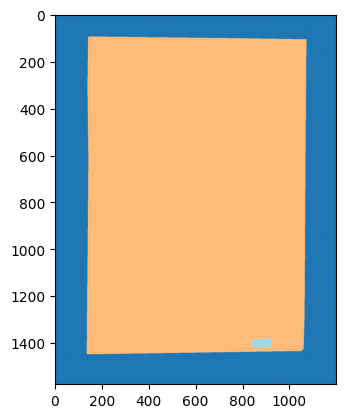

In [163]:
# 看看对不对
filelist = list(Path(r"D:\books-dataset\yolo-exp-etl-data\train\output-masks").rglob("*"))
file  = random.choice(filelist)
im = Image.open(file)
plt.imshow(im, cmap="tab20")

# EDA

In [ ]:
label = json.load(
    open(
        r"D:\books-dataset\yolo-exp-etl-data\train\json_only\0103aa17eea4218c57_b.json", "r", encoding="utf-8"
    )
)

In [ ]:
len(label["shapes"])

52

In [1]:
for s in label["shapes"]:
    if s["shape_type"] == "polygon":
        if len(s["points"]) <= 2:
            print(len(s["points"]))
            label["shapes"].remove(s)


NameError: name 'label' is not defined

In [ ]:
len(label["shapes"])

51

In [ ]:
with open(r"D:\books-dataset\yolo-exp-etl-data\train\0103aa17eea4218c57_b.json", "w", encoding="utf-8") as f:
    f.write(json.dumps(label, indent=4))